# Linear Models

Topics
- optimization
- gradient descent
- regularization

In machine learning, optimization is used to find a minimum of a cost function. For some optimization problems, there are closed form solutions, for others iterative methods are necessary. Gradient descent is a versatile iterative method. In addition to the cost function, we need the first derivative (gradient) of the cost function with respect to the model parameters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Optimization in one dimension - finding the square root

This example is inspired by https://www.youtube.com/watch?v=nvXRJIBOREc&list=PLUl4u3cNGP63oMNUHXqIUcrkS2PivhN3k&index=23

We would like to find the value of $w$ that minimizes the (cost) function $f(w) = 1/3 \cdot w^3 - c\cdot w$. Let's plot it for $c=22$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt


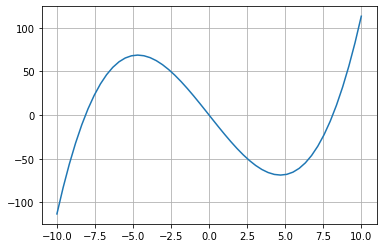

In [4]:
c=22
w = np.linspace(-10, 10, 50)
y = (1/3) * w**3 - c*w
plt.plot(w,y)
plt.grid(True)

Calculus tells us that the minimum (or maximum) occurs when the first derivative (gradient) is zero. The first derivate of $f(w)$ is:

$\frac{df}{dw} = w^2 - c$

To reach the minimum, we iteratively move in the opposite gradient direction - this is *gradient descent*:

$w_{k+1} = w_k - \eta \cdot \frac{df}{dw}$

$\eta$ is the step size, also called learning rate. In our example, we have:

$w_{k+1} = w_k - \eta \cdot \left(  w_k^2 - c \right)$

In [5]:
def gradient_descent(w, c, learning_rate, steps):
    for j in range(steps):
        print("{}: {}".format(j, w))
        w = w - learning_rate * ( w**2 - c)
    return w

To run our gradient descent, we provide:
- starting value for $w$ (what we are trying to find)
- parameter $c$
- learning rate $\eta$

In [6]:
c = 22
sqrt_c = gradient_descent(c/2, c, 0.1, 5)

0: 11.0
1: 1.0999999999999996
2: 3.179
3: 4.368395899999999
4: 4.660107626086319


What we were doing by finding $w$ that minimizes $f(w)$ is finding the square root of $c=22$.

In [7]:
print("sqrt({}): numpy={}, gd={}".format(c, np.sqrt(c), sqrt_c))

sqrt(22): numpy=4.69041575982343, gd=4.688447317415532


How do starting value, learning rate and number of iterations affect the end result? Experiment.

## Optimization in higher dimensions 
![](raschka_04_04.png)

reference: https://github.com/rasbt/python-machine-learning-book-3rd-edition/blob/master/ch04/ch04.ipynb

### Gradient descent for linear regression

Ordinary least squares has a closed-form solution (an equation). However, we can use it as an example for gradient descent.

Some data:

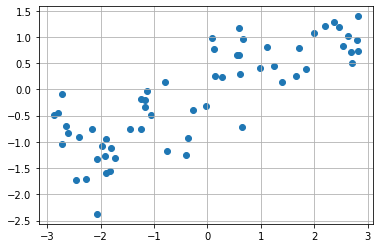

In [8]:
import mglearn
x, y = mglearn.datasets.make_wave(n_samples=60)

plt.scatter(x, y)
plt.grid(True)

Our model is a 1D line:  
$\hat{y} = wx+b$

we would like to find parameters $w$ and $b$, such that the mean-squared error is minimized.

The mean-squared error, our cost function is given by:  
$\begin{gathered}
f(w, b) = \frac{1}{n_{samples}}\sum_{i=1}^{n_{samples}} \left(  y_i - \hat{y_i}\right)^2\\
f(w, b) = \frac{1}{n_{samples}}\sum_{i=1}^{n_{samples}} \left(  y_i - (wx_i+b) \right)^2
\end{gathered}$ 

We would like to use gradient descent to find $w$ and $b$:  
$\begin{gathered}
w_{k+1} = w_k - \eta \frac{\partial f(w, b)}{\partial w}\\
b_{k+1} = b_k - \eta \frac{\partial f(w, b)}{\partial b}
\end{gathered}$ 

We need the partial derivatives of the cost function:  
$\begin{gathered}
\frac{\partial f(w, b)}{\partial w} = \frac{1}{n_{samples}}\sum_{i=1}^{n_{samples}} -2x_i\left( y_i - (wx_i+b) \right)\\
\frac{\partial f(w, b)}{\partial b} = \frac{1}{n_{samples}}\sum_{i=1}^{n_{samples}} -2\left( y_i - (wx_i+b) \right)
\end{gathered}$ 


In [9]:
def gradient_descent_step(x, y, w, b, eta):
    df_dw = 0
    df_db = 0
    
    # summation
    for i in range(len(x)):
        df_dw += -2*x[i]*(y[i] - (w*x[i] + b))
        df_db += -2*(y[i] - (w*x[i] + b))
    
    # take the average
    df_dw = df_dw / len(x)
    df_db = df_db / len(x)
    
    # gradient descent step
    w = w - eta * df_dw 
    b = b - eta * df_db 
    
    return w, b

In [10]:
def gradient_descent(x, y, w, b, eta, steps):
    for j in range(steps):
        w, b = gradient_descent_step(x, y, w, b, eta)
        
        if j%10 == 0:
            print("{}: w={:.2f}, b={:.2f}".format(j, w, b))
    return w, b

In [11]:
w, b = gradient_descent(x.squeeze(), y, 0, 0, 0.01, 100)
print(w, b)

0: w=0.03, b=-0.00
10: w=0.23, b=-0.02
20: w=0.32, b=-0.04
30: w=0.37, b=-0.04
40: w=0.40, b=-0.05
50: w=0.41, b=-0.05
60: w=0.42, b=-0.05
70: w=0.42, b=-0.05
80: w=0.42, b=-0.05
90: w=0.42, b=-0.06
0.4206099509634103 -0.056393244609342426


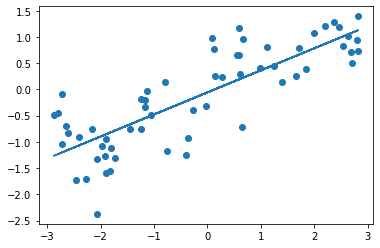

In [12]:
line = w * x.squeeze() + b
plt.scatter(x,y);
plt.plot(x, line)

In [13]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y, line)

0.28714599244213423

Compare to Scikit-learn `LinearRegression()`

In [14]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=True)
model.fit(x, y)
print(model.coef_)
print(model.intercept_)
y_pred = model.predict(x)
mean_squared_error(y, y_pred)

[0.42073384]
-0.05983245830361801


0.2871339468126629

### More *implementing from scratch*
Check out the github page https://github.com/joelgrus/data-science-from-scratch

and the corresponding book *Data Science from Scratch* by Joel Grus.

## Regularization terms 
### $l_2$ regularization

With an $l_2$ regularization term, we are allowing the $w$'s to only be on a circle. Can you see why a circle?

Think about all the $w_1$ and $w_2$ that satisfy $w_1^2 + w_2^2 = 1$ - this is a circle of radius 1.

![](raschka_04_05.png)  
reference: https://github.com/rasbt/python-machine-learning-book-3rd-edition/blob/master/ch04/ch04.ipynb


### $l_1$ regularization

With an $l_1$ regularization term, we are allowing the $w$'s to only be on a diamond. Can you see why a diamond?

Think about all the $w_1$ and $w_2$ that satisfy $\vert w_1\vert + \vert w_2\vert = 1$. When $w_1=1$, $w_2=0$ and vice-versa. Values inbetween lie on a straight line. This is a diamond.

![](raschka_04_06.png)  
reference: https://github.com/rasbt/python-machine-learning-book-3rd-edition/blob/master/ch04/ch04.ipynb

### More details
The github repository  https://github.com/rasbt/python-machine-learning-book-3rd-edition/

and corresponding book *Python Machine Learning 3rd Edition* by Sebastian Raschka provide more details for many algorithms.